<a href="https://colab.research.google.com/github/santiagorodmon/TelecomX_LATAM/blob/main/01_extraccion_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Informe de Análisis de Evasión de Clientes - Telecom X

## Importación de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

datos = pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [2]:
datos.shape

(7267, 6)

## 3. Desanidado de columnas anidadas

In [3]:
columnas_anidadas = ['customer', 'phone', 'internet', 'account']
datos_final = pd.concat([datos.drop(columns=columnas_anidadas)] +
                     [pd.json_normalize(datos[col]) for col in columnas_anidadas], axis=1)
datos_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
datos_final.shape

(7267, 21)

In [5]:
datos_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


## 4. Limpieza y tratamiento de datos

### 4.1 Verificación inicial de nulos y duplicados

In [6]:
datos_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [7]:
datos_final.duplicated().sum()

np.int64(0)

### 4.2 Conversión de tipos de datos

In [8]:
datos_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Observamos que `Charges.Total` es de tipo object (texto). Lo convertimos a numérico.

In [9]:
datos_final['Charges.Total'] = pd.to_numeric(datos_final['Charges.Total'], errors='coerce')
datos_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Verificamos datos nulos despues de la conversion

In [10]:
datos_final['Charges.Total'].isnull().sum()

np.int64(11)

### 4.3 Imputación de nulos en Charges.Total

Se encontraron 11 nulos es Charges.Total, Verificamos si corresponden a clientes nuevos (tenure = 0)

In [11]:
nulos_Charges_Total = datos_final[datos_final['Charges.Total'].isnull()]
nulos_Charges_Total['tenure']

,tenure
975,0
1775,0
1955,0
2075,0
2232,0
2308,0
2930,0
3134,0
3203,0
4169,0


In [12]:
datos_final.loc[datos_final['Charges.Total'].isnull() & (datos_final['tenure'] == 0), 'Charges.Total'] = \
    datos_final.loc[datos_final['Charges.Total'].isnull() & (datos_final['tenure'] == 0), 'Charges.Monthly']

In [13]:
datos_final['Charges.Total'].isnull().sum()

np.int64(0)

In [14]:
datos_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


### 4.4 Creación de nueva variable: Valor_Diario

Dividimos el cargo mensual entre 30 días

In [15]:
datos_final['Valor_Diario'] = datos_final['Charges.Monthly'] / 30
datos_final['Valor_Diario'].describe()

,Valor_Diario
count,7267.000000
mean,2.157337
std,1.004319
min,0.608333
25%,1.180833
50%,2.343333
75%,2.995833
max,3.958333


### 4.5 Estandarización y traducción

Renombramos columnas al español y convertimos valores a formato binario cuando corresponde

In [16]:
traduccion = {'customerID': 'ID_Cliente', 'Churn': 'Evasion', 'gender': 'Genero', 'SeniorCitizen': 'Adulto_Mayor', 'Partner': 'Pareja', 'Dependents': 'Dependientes', 'tenure': 'Antiguedad', 'PhoneService': 'Servicio_Telefonico', 'MultipleLines': 'Multiples_Lineas', 'InternetService': 'Servicio_Internet', 'OnlineSecurity': 'Seguridad_Online', 'OnlineBackup': 'Backup_Online', 'DeviceProtection': 'Proteccion_Dispositivo', 'TechSupport': 'Soporte_Tecnico', 'StreamingTV': 'Streaming_TV', 'StreamingMovies': 'Streaming_Peliculas', 'Contract': 'Contrato', 'PaperlessBilling': 'Factura_Electronica', 'PaymentMethod': 'Metodo_Pago', 'Charges.Monthly': 'Cargo_Mensual', 'Charges.Total': 'Cargo_Total'}
datos_final.rename(columns=traduccion, inplace=True)
datos_final.head()

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Factura_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Valor_Diario
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


Convertir variables binarias a 0 - 1

In [17]:
binarias = ['Evasion', 'Pareja', 'Dependientes', 'Servicio_Telefonico', 'Factura_Electronica']
for columna in binarias:
    datos_final[columna] = datos_final[columna].map({'Yes': 1, 'No': 0})

datos_final.head(20)

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Factura_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Valor_Diario
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.90,267.40,2.796667
5,0013-MHZWF,0.0,Female,0,0,1,9,1,No,DSL,...,No,Yes,Yes,Yes,Month-to-month,1,Credit card (automatic),69.40,571.45,2.313333
6,0013-SMEOE,0.0,Female,1,1,0,71,1,No,Fiber optic,...,Yes,Yes,Yes,Yes,Two year,1,Bank transfer (automatic),109.70,7904.25,3.656667
7,0014-BMAQU,0.0,Male,0,1,0,63,1,Yes,Fiber optic,...,No,Yes,No,No,Two year,1,Credit card (automatic),84.65,5377.80,2.821667
8,0015-UOCOJ,0.0,Female,1,0,0,7,1,No,DSL,...,No,No,No,No,Month-to-month,1,Electronic check,48.20,340.35,1.606667
9,0016-QLJIS,0.0,Female,0,1,1,65,1,Yes,DSL,...,Yes,Yes,Yes,Yes,Two year,1,Mailed check,90.45,5957.90,3.015000


In [18]:
datos_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7267 non-null   object 
 1   Evasion                 7043 non-null   float64
 2   Genero                  7267 non-null   object 
 3   Adulto_Mayor            7267 non-null   int64  
 4   Pareja                  7267 non-null   int64  
 5   Dependientes            7267 non-null   int64  
 6   Antiguedad              7267 non-null   int64  
 7   Servicio_Telefonico     7267 non-null   int64  
 8   Multiples_Lineas        7267 non-null   object 
 9   Servicio_Internet       7267 non-null   object 
 10  Seguridad_Online        7267 non-null   object 
 11  Backup_Online           7267 non-null   object 
 12  Proteccion_Dispositivo  7267 non-null   object 
 13  Soporte_Tecnico         7267 non-null   object 
 14  Streaming_TV            7267 non-null   

In [19]:
datos_final[['Multiples_Lineas', 'Seguridad_Online', 'Backup_Online', 'Proteccion_Dispositivo','Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas']].head(20)

,Multiples_Lineas,Seguridad_Online,Backup_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas
0,No,No,Yes,No,Yes,Yes,No
1,Yes,No,No,No,No,No,Yes
2,No,No,No,Yes,No,No,No
3,No,No,Yes,Yes,No,Yes,Yes
4,No,No,No,No,Yes,Yes,No
5,No,No,No,No,Yes,Yes,Yes
6,No,Yes,Yes,Yes,Yes,Yes,Yes
7,Yes,Yes,No,No,Yes,No,No
8,No,Yes,No,No,No,No,No
9,Yes,Yes,Yes,Yes,Yes,Yes,Yes


In [20]:
datos_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7267 non-null   object 
 1   Evasion                 7043 non-null   float64
 2   Genero                  7267 non-null   object 
 3   Adulto_Mayor            7267 non-null   int64  
 4   Pareja                  7267 non-null   int64  
 5   Dependientes            7267 non-null   int64  
 6   Antiguedad              7267 non-null   int64  
 7   Servicio_Telefonico     7267 non-null   int64  
 8   Multiples_Lineas        7267 non-null   object 
 9   Servicio_Internet       7267 non-null   object 
 10  Seguridad_Online        7267 non-null   object 
 11  Backup_Online           7267 non-null   object 
 12  Proteccion_Dispositivo  7267 non-null   object 
 13  Soporte_Tecnico         7267 non-null   object 
 14  Streaming_TV            7267 non-null   

In [21]:
servicios = ['Multiples_Lineas', 'Seguridad_Online', 'Backup_Online', 'Proteccion_Dispositivo','Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas']
for col in servicios:
    datos_final[col] = datos_final[col].map({'Yes': 1, 'No': 0, 'No phone service': 2, 'No internet service': 2})

datos_final[['Multiples_Lineas', 'Seguridad_Online', 'Backup_Online', 'Proteccion_Dispositivo','Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas']].head(20)


,Multiples_Lineas,Seguridad_Online,Backup_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas
0,0,0,1,0,1,1,0
1,1,0,0,0,0,0,1
2,0,0,0,1,0,0,0
3,0,0,1,1,0,1,1
4,0,0,0,0,1,1,0
5,0,0,0,0,1,1,1
6,0,1,1,1,1,1,1
7,1,1,0,0,1,0,0
8,0,1,0,0,0,0,0
9,1,1,1,1,1,1,1


Traducir valores de columnas categóricas

In [22]:
datos_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7267 non-null   object 
 1   Evasion                 7043 non-null   float64
 2   Genero                  7267 non-null   object 
 3   Adulto_Mayor            7267 non-null   int64  
 4   Pareja                  7267 non-null   int64  
 5   Dependientes            7267 non-null   int64  
 6   Antiguedad              7267 non-null   int64  
 7   Servicio_Telefonico     7267 non-null   int64  
 8   Multiples_Lineas        7267 non-null   int64  
 9   Servicio_Internet       7267 non-null   object 
 10  Seguridad_Online        7267 non-null   int64  
 11  Backup_Online           7267 non-null   int64  
 12  Proteccion_Dispositivo  7267 non-null   int64  
 13  Soporte_Tecnico         7267 non-null   int64  
 14  Streaming_TV            7267 non-null   

In [23]:
datos_final['Genero']

,Genero
0,Female
1,Male
2,Male
3,Male
4,Female
...,...
7262,Female
7263,Male
7264,Male
7265,Male


In [24]:
datos_final['Genero'] = datos_final['Genero'].map({'Female': 'Femenino', 'Male': 'Masculino'})
datos_final['Genero']

,Genero
0,Femenino
1,Masculino
2,Masculino
3,Masculino
4,Femenino
...,...
7262,Femenino
7263,Masculino
7264,Masculino
7265,Masculino


In [25]:
datos_final['Servicio_Internet']

,Servicio_Internet
0,DSL
1,DSL
2,Fiber optic
3,Fiber optic
4,Fiber optic
...,...
7262,DSL
7263,Fiber optic
7264,DSL
7265,DSL


In [26]:
datos_final['Servicio_Internet'] = datos_final['Servicio_Internet'].map({'DSL': 'DSL', 'Fiber optic': 'Fibra óptica', 'No': 'No'})
datos_final['Servicio_Internet']

,Servicio_Internet
0,DSL
1,DSL
2,Fibra óptica
3,Fibra óptica
4,Fibra óptica
...,...
7262,DSL
7263,Fibra óptica
7264,DSL
7265,DSL


In [27]:
datos_final['Contrato']

,Contrato
0,One year
1,Month-to-month
2,Month-to-month
3,Month-to-month
4,Month-to-month
...,...
7262,One year
7263,Month-to-month
7264,Month-to-month
7265,Two year


In [28]:
datos_final['Contrato'] = datos_final['Contrato'].map({'Month-to-month': 'Mensual', 'One year': 'Anual', 'Two year': 'Bianual'})
datos_final['Contrato']

,Contrato
0,Anual
1,Mensual
2,Mensual
3,Mensual
4,Mensual
...,...
7262,Anual
7263,Mensual
7264,Mensual
7265,Bianual


In [29]:
datos_final['Metodo_Pago']

,Metodo_Pago
0,Mailed check
1,Mailed check
2,Electronic check
3,Electronic check
4,Mailed check
...,...
7262,Mailed check
7263,Electronic check
7264,Mailed check
7265,Mailed check


In [30]:
datos_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7267 non-null   object 
 1   Evasion                 7043 non-null   float64
 2   Genero                  7267 non-null   object 
 3   Adulto_Mayor            7267 non-null   int64  
 4   Pareja                  7267 non-null   int64  
 5   Dependientes            7267 non-null   int64  
 6   Antiguedad              7267 non-null   int64  
 7   Servicio_Telefonico     7267 non-null   int64  
 8   Multiples_Lineas        7267 non-null   int64  
 9   Servicio_Internet       7267 non-null   object 
 10  Seguridad_Online        7267 non-null   int64  
 11  Backup_Online           7267 non-null   int64  
 12  Proteccion_Dispositivo  7267 non-null   int64  
 13  Soporte_Tecnico         7267 non-null   int64  
 14  Streaming_TV            7267 non-null   

In [31]:
datos_final['Metodo_Pago'] = datos_final['Metodo_Pago'].map({'Electronic check': 'Cheque electrónico', 'Mailed check': 'Cheque por correo', 'Bank transfer (automatic)': 'Transferencia bancaria', 'Credit card (automatic)': 'Tarjeta de crédito'})
datos_final['Metodo_Pago']

,Metodo_Pago
0,Cheque por correo
1,Cheque por correo
2,Cheque electrónico
3,Cheque electrónico
4,Cheque por correo
...,...
7262,Cheque por correo
7263,Cheque electrónico
7264,Cheque por correo
7265,Cheque por correo


In [32]:
datos_final.head()

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Factura_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Valor_Diario
0,0002-ORFBO,0.0,Femenino,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,1,Cheque por correo,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensual,0,Cheque por correo,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Masculino,0,0,0,4,1,0,Fibra óptica,...,1,0,0,0,Mensual,1,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Masculino,1,1,0,13,1,0,Fibra óptica,...,1,0,1,1,Mensual,1,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Femenino,1,1,0,3,1,0,Fibra óptica,...,0,1,1,0,Mensual,1,Cheque por correo,83.9,267.40,2.796667


In [33]:
datos_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7267 non-null   object 
 1   Evasion                 7043 non-null   float64
 2   Genero                  7267 non-null   object 
 3   Adulto_Mayor            7267 non-null   int64  
 4   Pareja                  7267 non-null   int64  
 5   Dependientes            7267 non-null   int64  
 6   Antiguedad              7267 non-null   int64  
 7   Servicio_Telefonico     7267 non-null   int64  
 8   Multiples_Lineas        7267 non-null   int64  
 9   Servicio_Internet       7267 non-null   object 
 10  Seguridad_Online        7267 non-null   int64  
 11  Backup_Online           7267 non-null   int64  
 12  Proteccion_Dispositivo  7267 non-null   int64  
 13  Soporte_Tecnico         7267 non-null   int64  
 14  Streaming_TV            7267 non-null   

### 4.6 Eliminación de registros con Evasión nula

Observamos que hay 224 registros con `Evasion` nula. Dado que no representan un patrón claro y son solo el 3%, los eliminamos.

In [34]:
datos_final['Evasion'].value_counts()

,count
Evasion,
0.0,5174
1.0,1869


In [35]:
datos_final = datos_final.dropna(subset=['Evasion']).copy()

In [36]:
datos_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7043 non-null   object 
 1   Evasion                 7043 non-null   float64
 2   Genero                  7043 non-null   object 
 3   Adulto_Mayor            7043 non-null   int64  
 4   Pareja                  7043 non-null   int64  
 5   Dependientes            7043 non-null   int64  
 6   Antiguedad              7043 non-null   int64  
 7   Servicio_Telefonico     7043 non-null   int64  
 8   Multiples_Lineas        7043 non-null   int64  
 9   Servicio_Internet       7043 non-null   object 
 10  Seguridad_Online        7043 non-null   int64  
 11  Backup_Online           7043 non-null   int64  
 12  Proteccion_Dispositivo  7043 non-null   int64  
 13  Soporte_Tecnico         7043 non-null   int64  
 14  Streaming_TV            7043 non-null   int64

## 5. Análisis exploratorio de datos

### 5.1 Estadísticas descriptivas de variables numéricas

In [38]:
numericas = ['Antiguedad', 'Cargo_Mensual', 'Cargo_Total', 'Valor_Diario']
datos_final[numericas].describe().round(2)

,Antiguedad,Cargo_Mensual,Cargo_Total,Valor_Diario
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.80,2.16
std,24.56,30.09,2266.73,1.00
min,0.00,18.25,18.80,0.61
25%,9.00,35.50,398.55,1.18
50%,29.00,70.35,1394.55,2.34
75%,55.00,89.85,3786.60,2.99
max,72.00,118.75,8684.80,3.96


### 5.2 Boxplots de variables numéricas por Evasión

/tmp/ipykernel_45141/1896961805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasion', y='Antiguedad', data=datos_final, ax=axes[0,0], palette=['#3498db', '#e74c3c'])
/tmp/ipykernel_45141/1896961805.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['No evade', 'Evade'])
/tmp/ipykernel_45141/1896961805.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasion', y='Cargo_Mensual', data=datos_final, ax=axes[0,1], palette=['#3498db', '#e74c3c'])
/tmp/ipykernel_45141/1896961805.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. a

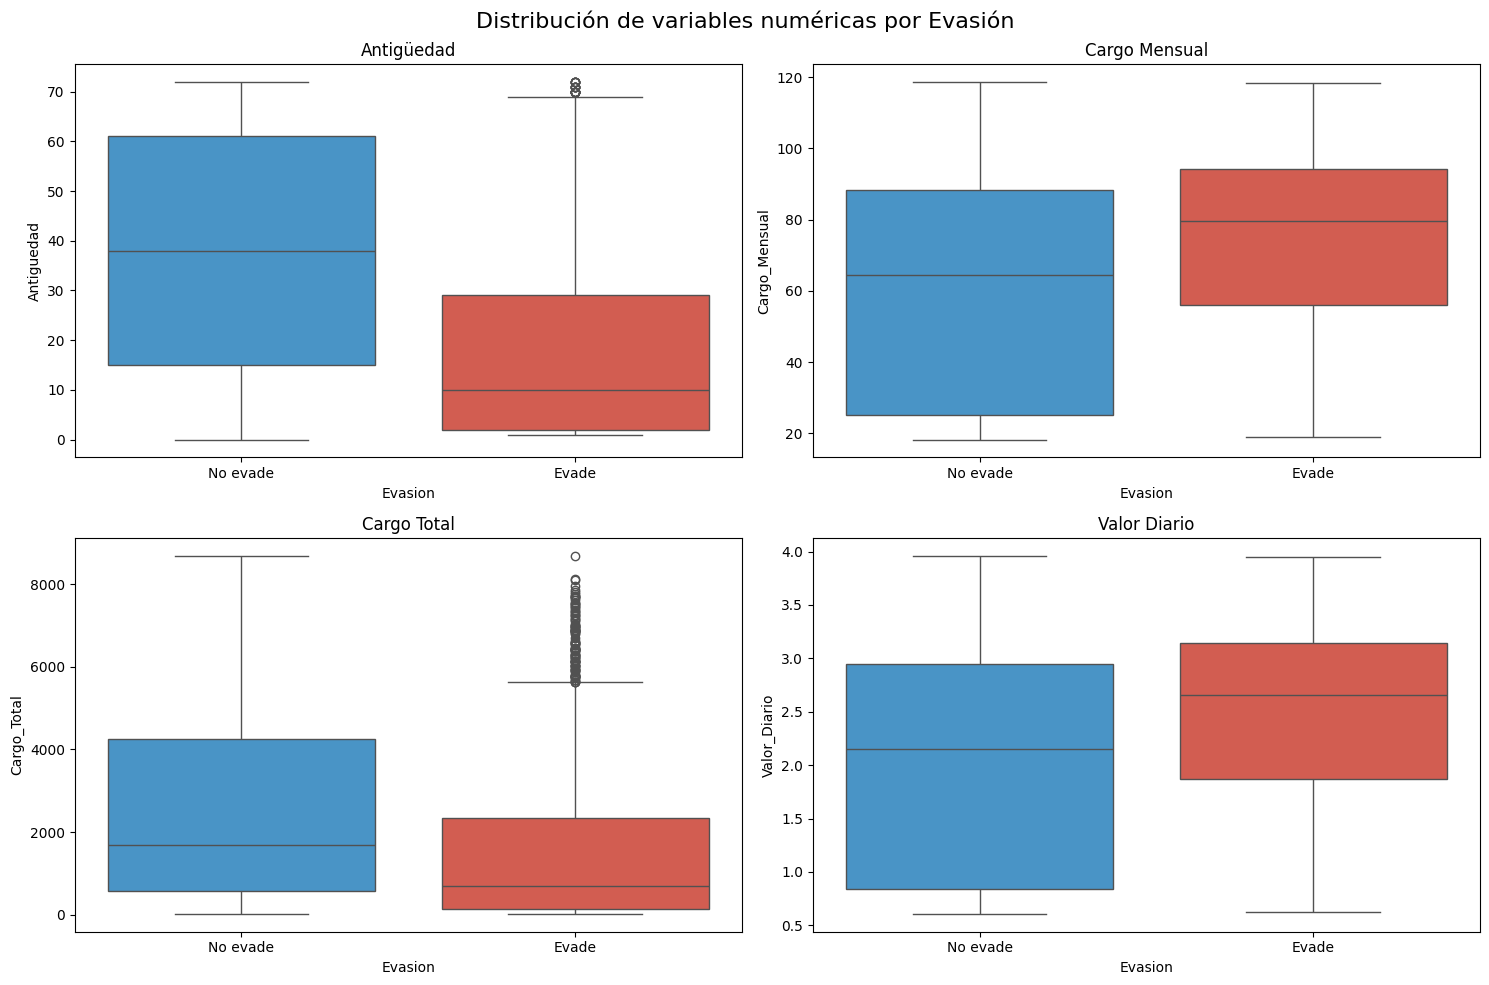

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribución de variables numéricas por Evasión', fontsize=16)

sns.boxplot(x='Evasion', y='Antiguedad', data=datos_final, ax=axes[0,0], palette=['#3498db', '#e74c3c'])
axes[0,0].set_title('Antigüedad')
axes[0,0].set_xticklabels(['No evade', 'Evade'])

sns.boxplot(x='Evasion', y='Cargo_Mensual', data=datos_final, ax=axes[0,1], palette=['#3498db', '#e74c3c'])
axes[0,1].set_title('Cargo Mensual')
axes[0,1].set_xticklabels(['No evade', 'Evade'])

sns.boxplot(x='Evasion', y='Cargo_Total', data=datos_final, ax=axes[1,0], palette=['#3498db', '#e74c3c'])
axes[1,0].set_title('Cargo Total')
axes[1,0].set_xticklabels(['No evade', 'Evade'])

sns.boxplot(x='Evasion', y='Valor_Diario', data=datos_final, ax=axes[1,1], palette=['#3498db', '#e74c3c'])
axes[1,1].set_title('Valor Diario')
axes[1,1].set_xticklabels(['No evade', 'Evade'])

plt.tight_layout()
plt.show()

### 5.3 Análisis de variables categóricas


ANÁLISIS DE: CONTRATO
          No evade (%)  Evade (%)  Total clientes
Contrato                                         
Anual             88.7       11.3            1473
Bianual           97.2        2.8            1695
Mensual           57.3       42.7            3875


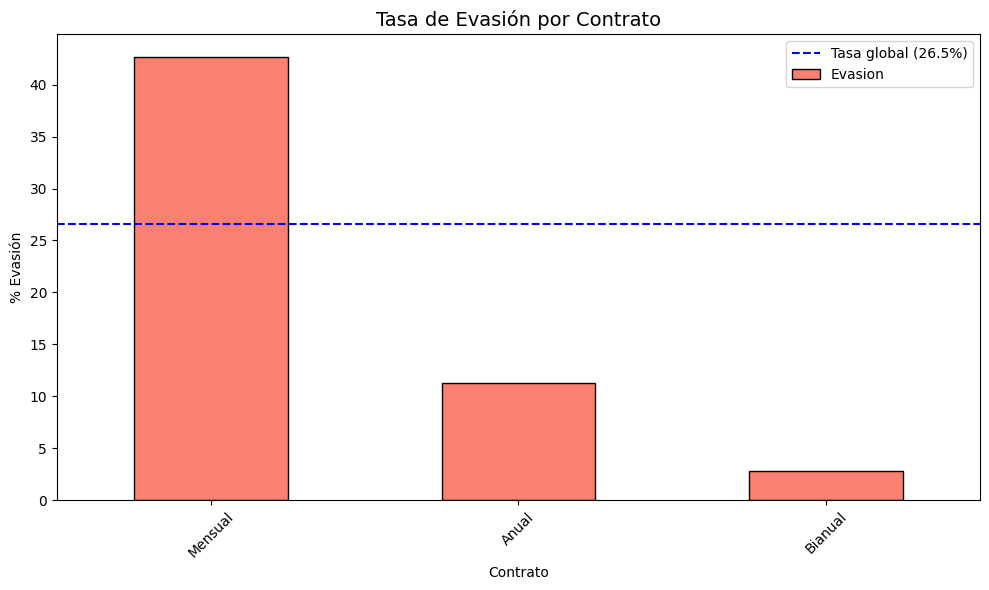


ANÁLISIS DE: SERVICIO_INTERNET
                   No evade (%)  Evade (%)  Total clientes
Servicio_Internet                                         
DSL                        81.0       19.0            2421
Fibra óptica               58.1       41.9            3096
No                         92.6        7.4            1526


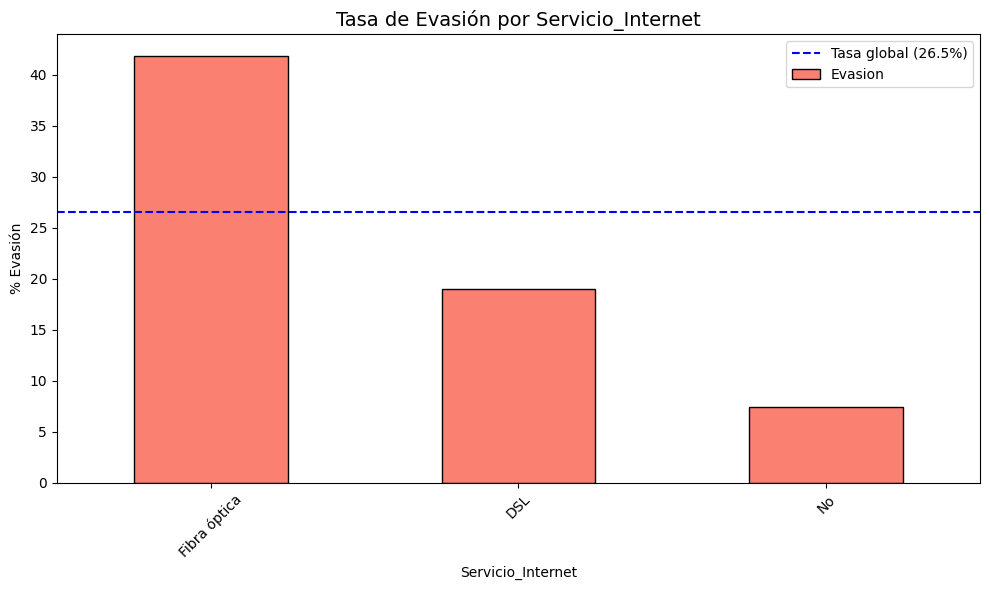


ANÁLISIS DE: METODO_PAGO
                        No evade (%)  Evade (%)  Total clientes
Metodo_Pago                                                    
Cheque electrónico              54.7       45.3            2365
Cheque por correo               80.9       19.1            1612
Tarjeta de crédito              84.8       15.2            1522
Transferencia bancaria          83.3       16.7            1544


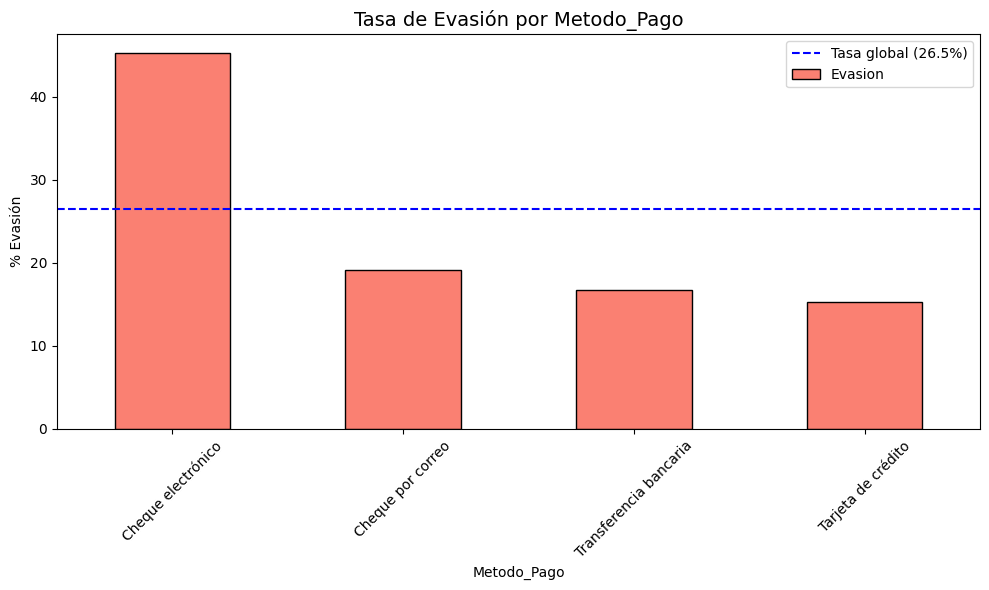


ANÁLISIS DE: GENERO
           No evade (%)  Evade (%)  Total clientes
Genero                                            
Femenino           73.1       26.9            3488
Masculino          73.8       26.2            3555


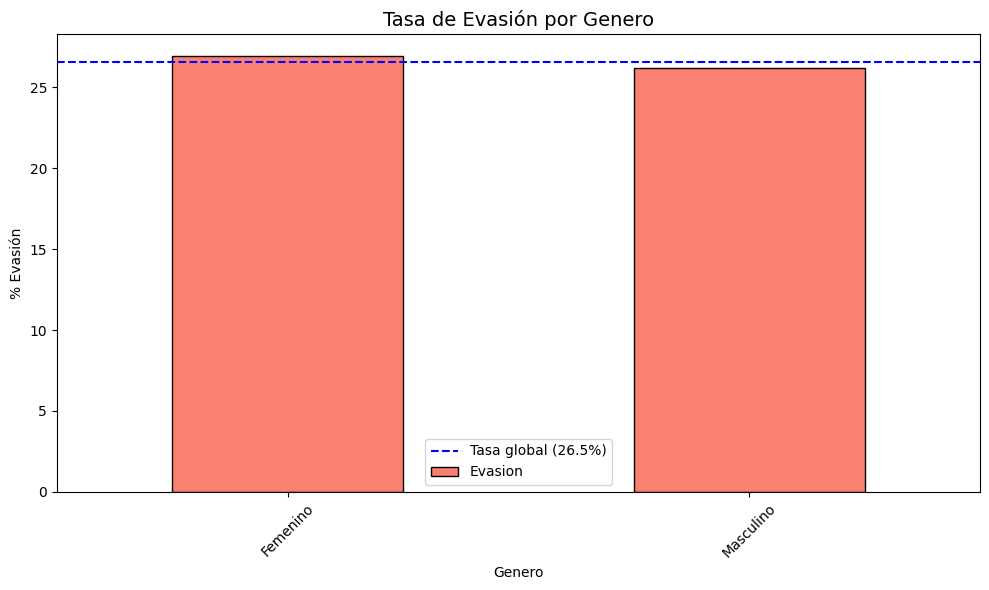


ANÁLISIS DE: FACTURA_ELECTRONICA
                     No evade (%)  Evade (%)  Total clientes
Factura_Electronica                                         
0                            83.7       16.3            2872
1                            66.4       33.6            4171


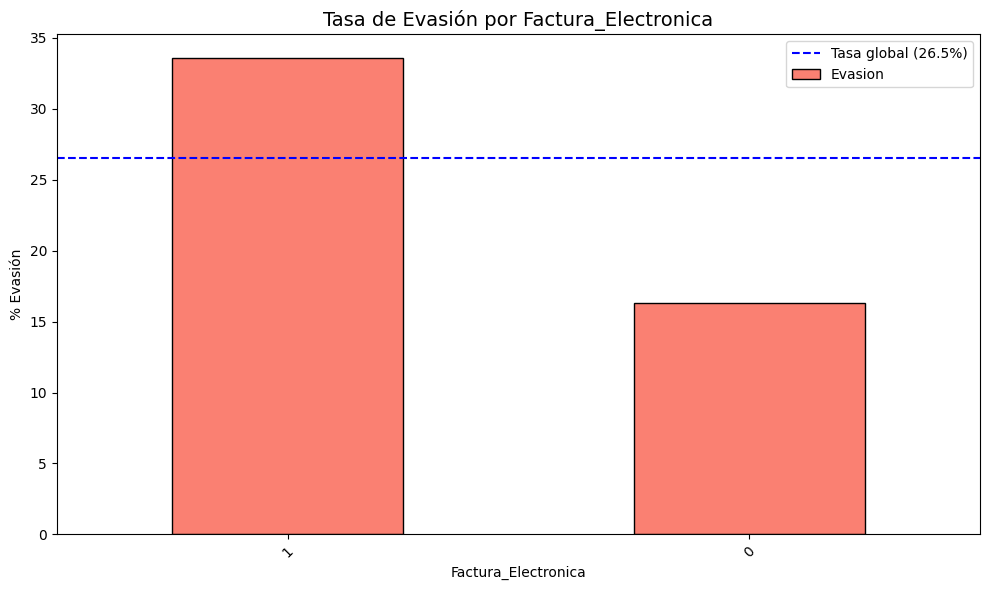


ANÁLISIS DE: PAREJA
        No evade (%)  Evade (%)  Total clientes
Pareja                                         
0               67.0       33.0            3641
1               80.3       19.7            3402


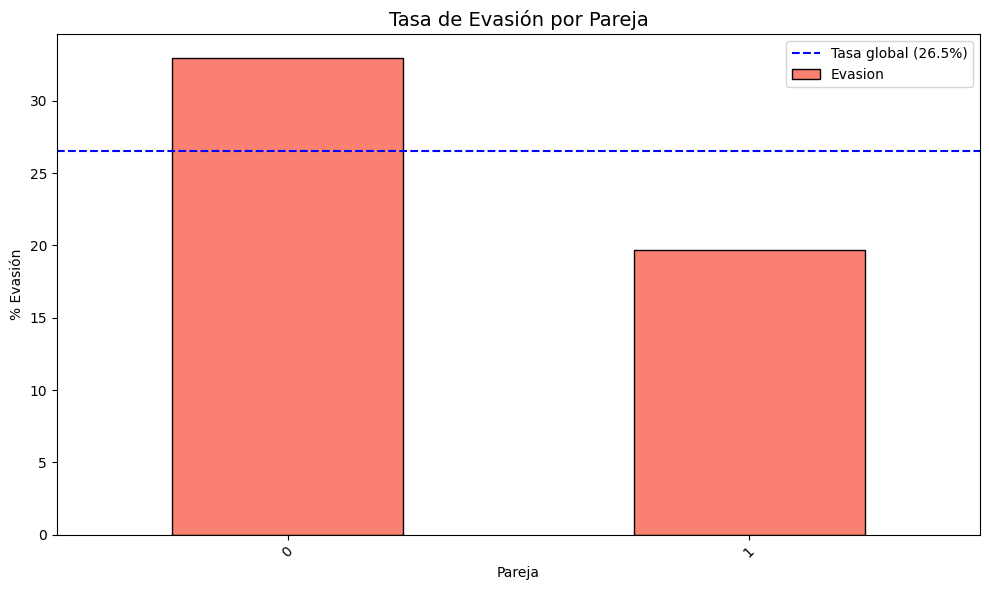


ANÁLISIS DE: DEPENDIENTES
              No evade (%)  Evade (%)  Total clientes
Dependientes                                         
0                     68.7       31.3            4933
1                     84.5       15.5            2110


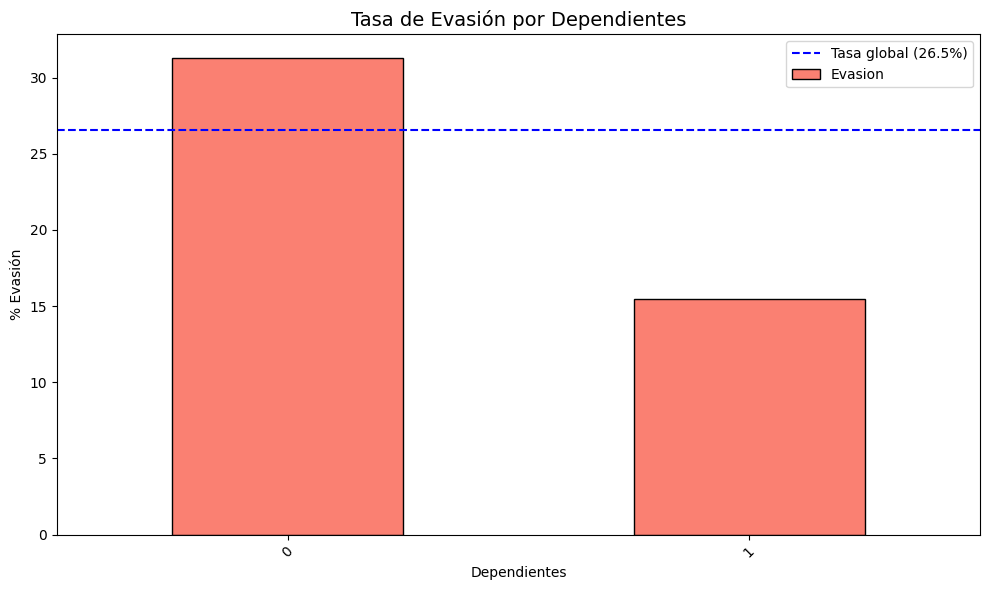

In [44]:
def analizar_categorica(col):
    """
    Realiza un análisis estadístico y visual de variables categóricas
    respecto a la variable objetivo 'Evasion'.
    """
    print(f"\n{'='*50}")
    print(f"ANÁLISIS DE: {col.upper()}")
    print(f"{'='*50}")

    # 1. Tabla de contingencia normalizada
    tabla = pd.crosstab(datos_final[col], datos_final['Evasion'], normalize='index') * 100
    tabla.columns = ['No evade (%)', 'Evade (%)']

    # Añadimos el volumen de datos para contexto
    tabla['Total clientes'] = datos_final[col].value_counts()

    print(tabla.round(1))

    # 2. Visualización
    plt.figure(figsize=(10, 6))

    # Calculamos la tasa de evasión por categoría
    tasa = (datos_final.groupby(col)['Evasion'].mean() * 100).sort_values(ascending=False)

    # Gráfico de barras
    tasa.plot(kind='bar', color='salmon', edgecolor='black')

    # Línea de referencia (Tasa global de evasión)
    tasa_global = datos_final['Evasion'].mean() * 100
    plt.axhline(y=tasa_global, color='blue', linestyle='--', label=f'Tasa global ({tasa_global:.1f}%)')

    plt.title(f'Tasa de Evasión por {col}', fontsize=14)
    plt.ylabel('% Evasión')
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Ejecución del Análisis ---

# Lista de variables categóricas a procesar
categoricas = [
    'Contrato', 'Servicio_Internet', 'Metodo_Pago', 'Genero',
    'Factura_Electronica', 'Pareja', 'Dependientes'
]

# Bucle para analizar cada variable
for col in categoricas:
    if col in datos_final.columns:
        analizar_categorica(col)
    else:
        print(f"⚠️ La columna '{col}' no se encuentra en el DataFrame.")

### 5.4 Análisis de servicios adicionales


ANÁLISIS DE: SEGURIDAD_ONLINE
                  No evade (%)  Evade (%)  Total clientes
Seguridad_Online                                         
0                         58.2       41.8            3498
1                         85.4       14.6            2019
2                         92.6        7.4            1526


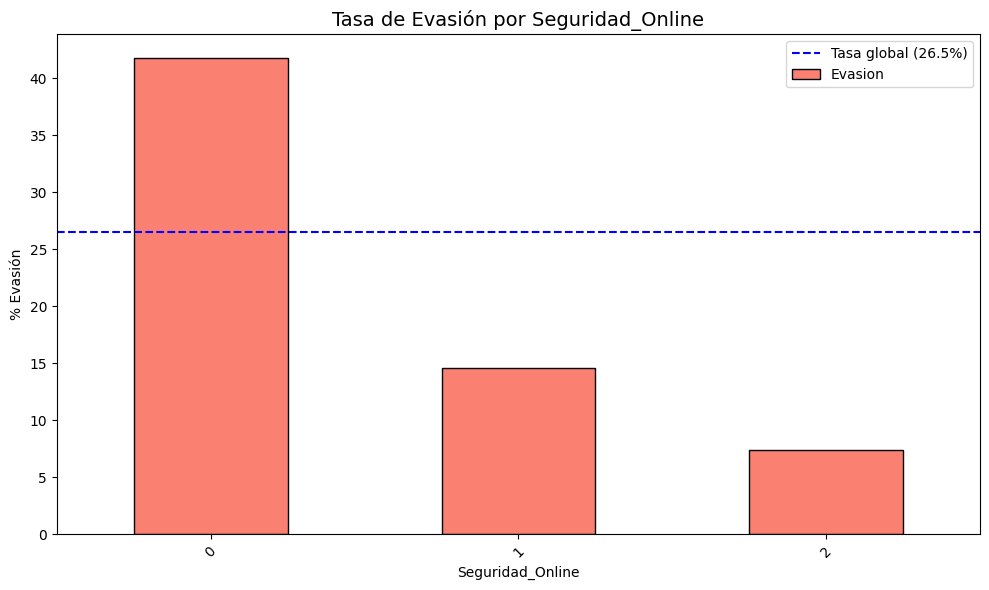


ANÁLISIS DE: BACKUP_ONLINE
               No evade (%)  Evade (%)  Total clientes
Backup_Online                                         
0                      60.1       39.9            3088
1                      78.5       21.5            2429
2                      92.6        7.4            1526


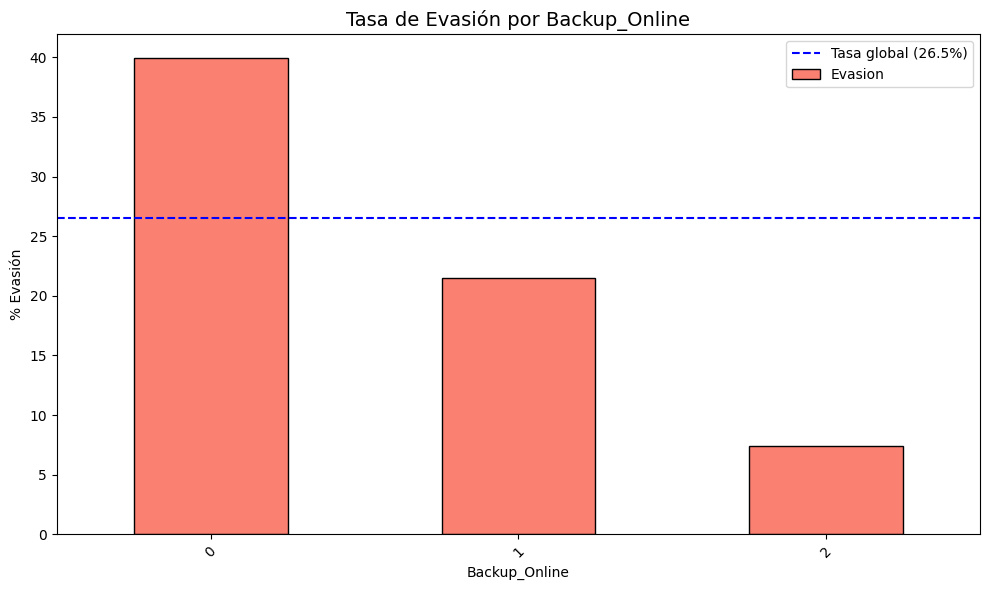


ANÁLISIS DE: PROTECCION_DISPOSITIVO
                        No evade (%)  Evade (%)  Total clientes
Proteccion_Dispositivo                                         
0                               60.9       39.1            3095
1                               77.5       22.5            2422
2                               92.6        7.4            1526


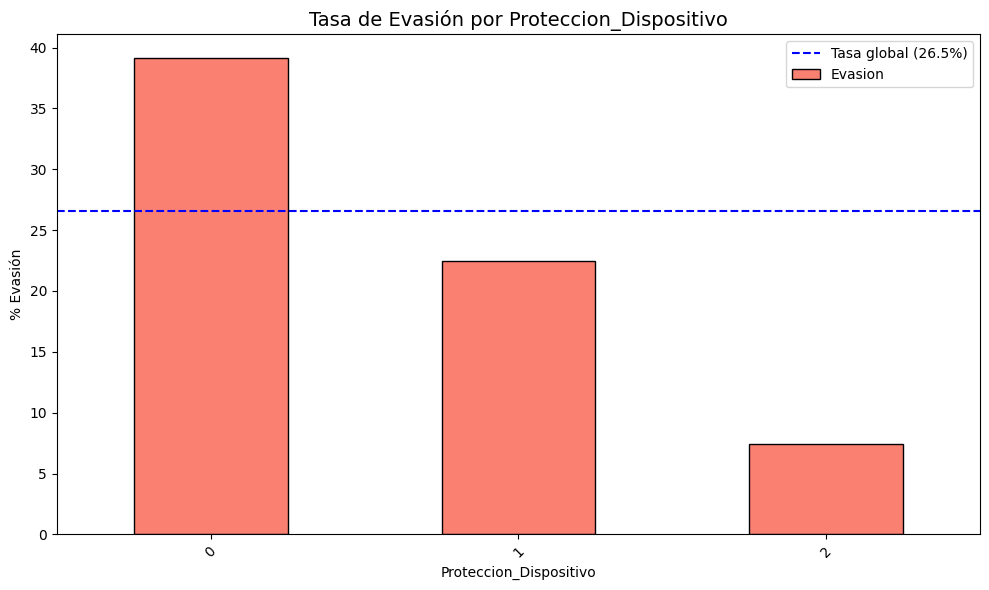


ANÁLISIS DE: SOPORTE_TECNICO
                 No evade (%)  Evade (%)  Total clientes
Soporte_Tecnico                                         
0                        58.4       41.6            3473
1                        84.8       15.2            2044
2                        92.6        7.4            1526


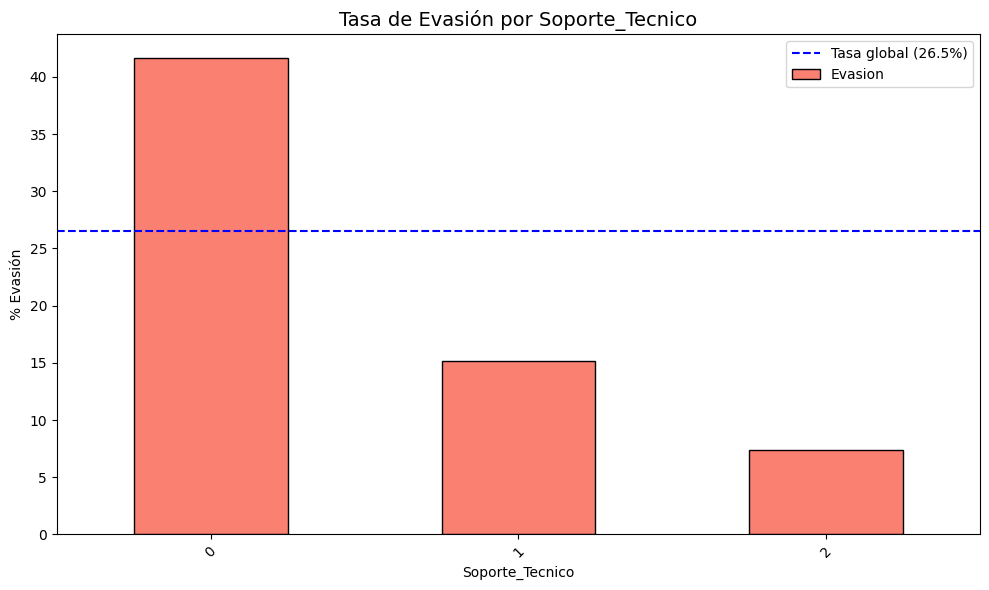


ANÁLISIS DE: STREAMING_TV
              No evade (%)  Evade (%)  Total clientes
Streaming_TV                                         
0                     66.5       33.5            2810
1                     69.9       30.1            2707
2                     92.6        7.4            1526


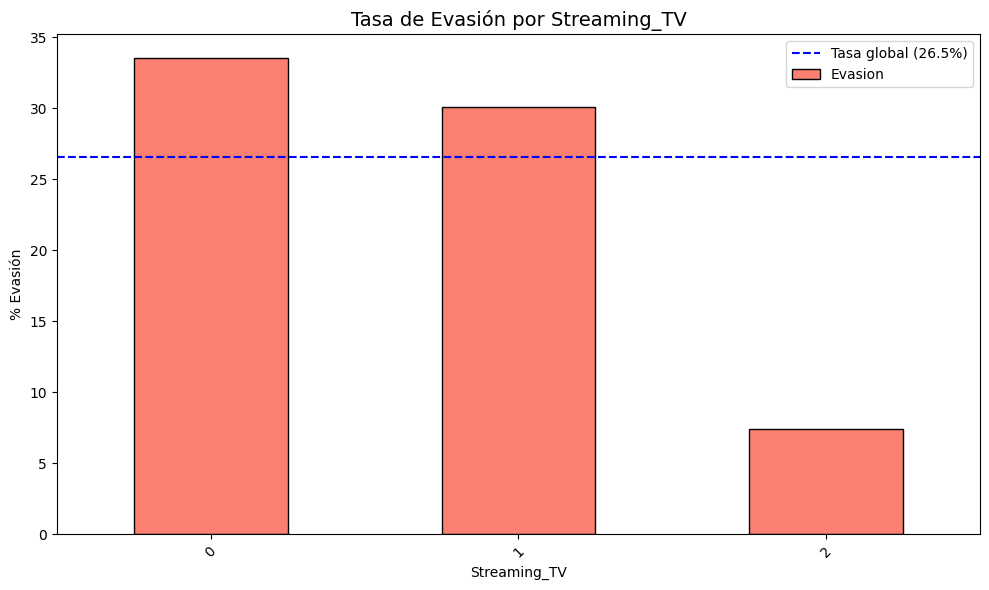


ANÁLISIS DE: STREAMING_PELICULAS
                     No evade (%)  Evade (%)  Total clientes
Streaming_Peliculas                                         
0                            66.3       33.7            2785
1                            70.1       29.9            2732
2                            92.6        7.4            1526


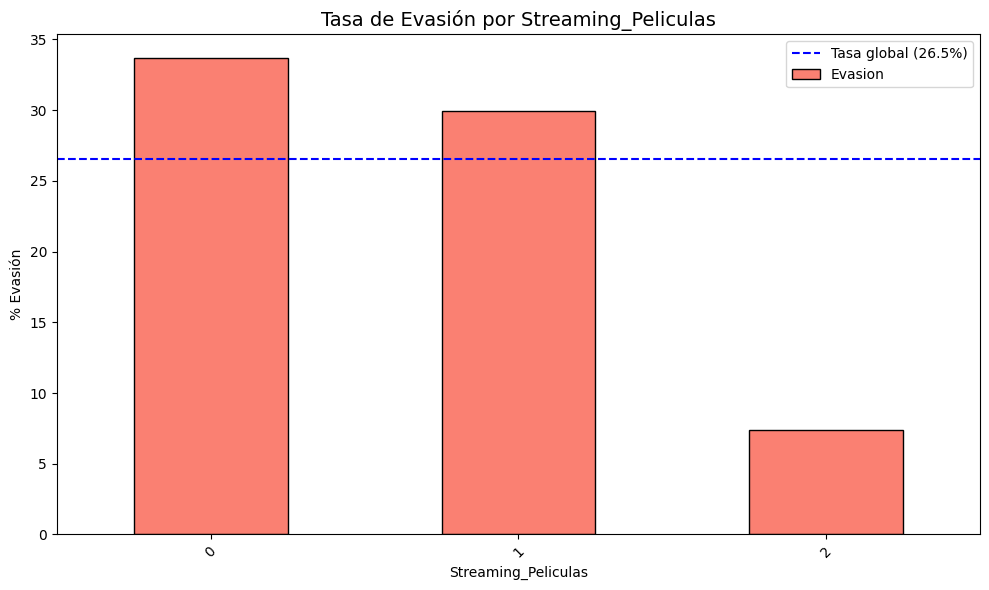

In [45]:
servicios = ['Seguridad_Online', 'Backup_Online', 'Proteccion_Dispositivo','Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas']
for s in servicios:
  analizar_categorica(s)

### 5.5 Tasa de evasión por rangos de antigüedad

RESUMEN DE EVASIÓN POR ANTIGÜEDAD
----------------------------------------
                  Total Clientes  Tasa Evasión (%)
rango_antiguedad                                  
(-0.072, 7.2]               1612             51.80
(7.2, 14.4]                  759             34.78
(14.4, 21.6]                 570             29.65
(21.6, 28.8]                 556             22.66
(28.8, 36.0]                 545             21.47
(36.0, 43.2]                 444             22.07
(43.2, 50.4]                 452             15.93
(50.4, 57.6]                 495             14.14
(57.6, 64.8]                 501              9.18
(64.8, 72.0]                1109              6.49


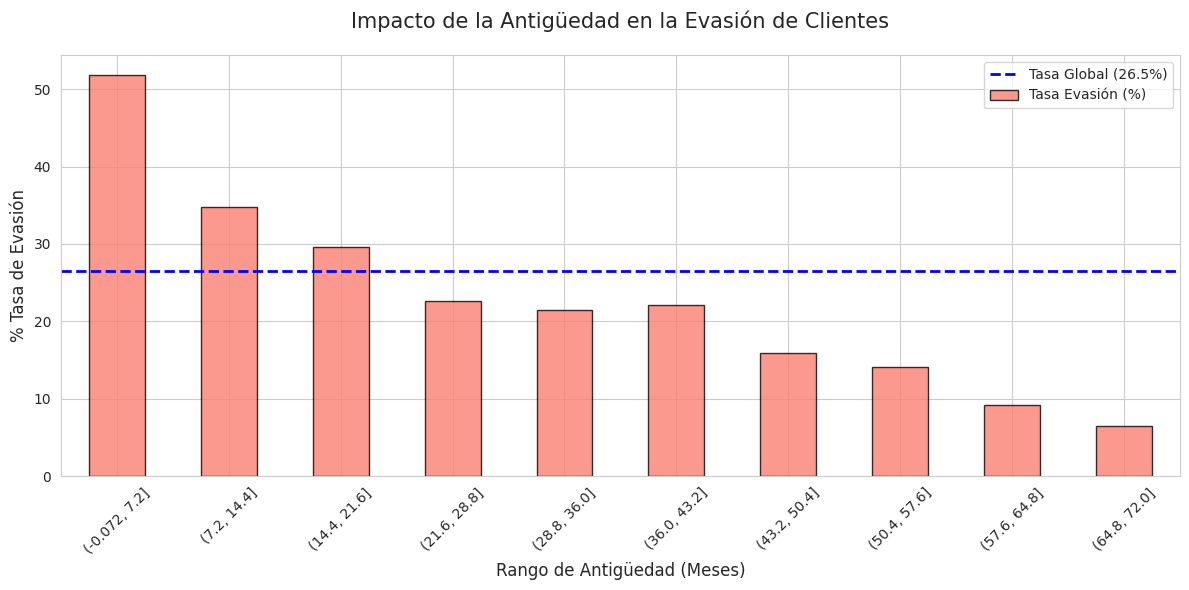

In [46]:
# 1. Creación de rangos de antigüedad (Dividido en 10 bins iguales)
datos_final['rango_antiguedad'] = pd.cut(datos_final['Antiguedad'], bins=10)

# 2. Cálculo de métricas por rango
# 'count' nos da el volumen de clientes y 'mean' la tasa de evasión
tabla_rangos = datos_final.groupby('rango_antiguedad', observed=False)['Evasion'].agg(['count', 'mean'])
tabla_rangos['mean'] = tabla_rangos['mean'] * 100
tabla_rangos.columns = ['Total Clientes', 'Tasa Evasión (%)']

# Imprimir tabla de resumen
print("RESUMEN DE EVASIÓN POR ANTIGÜEDAD")
print("-" * 40)
print(tabla_rangos.round(2))

# 3. Visualización
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Gráfico de barras
ax = tabla_rangos['Tasa Evasión (%)'].plot(kind='bar', color='salmon', edgecolor='black', alpha=0.8)

# Línea de referencia (Tasa global)
tasa_global = datos_final['Evasion'].mean() * 100
plt.axhline(y=tasa_global, color='blue', linestyle='--', linewidth=2, label=f'Tasa Global ({tasa_global:.1f}%)')

# Estética del gráfico
plt.title('Impacto de la Antigüedad en la Evasión de Clientes', fontsize=15, pad=20)
plt.xlabel('Rango de Antigüedad (Meses)', fontsize=12)
plt.ylabel('% Tasa de Evasión', fontsize=12)
plt.xticks(rotation=45)
plt.legend()

# Limpieza y visualización
plt.tight_layout()
plt.show()

# 4. Limpieza del DataFrame (Eliminar columna temporal)
datos_final.drop('rango_antiguedad', axis=1, inplace=True)

### 5.6 Matriz de correlación

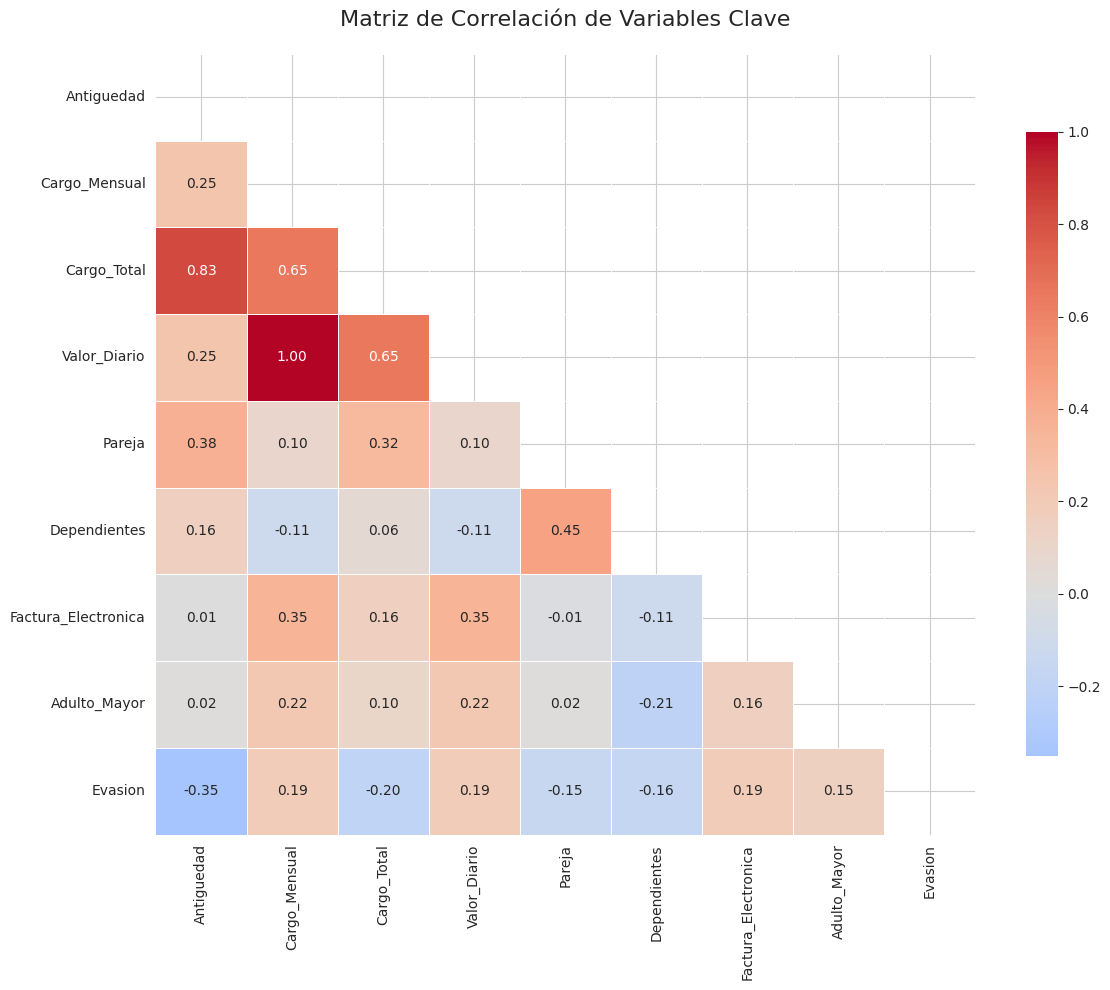

------------------------------
CORRELACIÓN DIRECTA CON EVASIÓN
------------------------------
Evasion                1.000
Cargo_Mensual          0.193
Valor_Diario           0.193
Factura_Electronica    0.192
Adulto_Mayor           0.151
Pareja                -0.150
Dependientes          -0.164
Cargo_Total           -0.198
Antiguedad            -0.352
Name: Evasion, dtype: float64


In [48]:
# 1. Selección de variables para el análisis de correlación
corr_vars = [
    'Antiguedad', 'Cargo_Mensual', 'Cargo_Total', 'Valor_Diario',
    'Pareja', 'Dependientes', 'Factura_Electronica', 'Adulto_Mayor', 'Evasion'
]

# 2. Cálculo de la matriz de correlación (Método Pearson por defecto)
corr_matrix = datos_final[corr_vars].corr()

# 3. Configuración del gráfico (Heatmap)
plt.figure(figsize=(12, 10))

# Creamos una máscara para ocultar la mitad superior (opcional, mejora la lectura)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Dibujar el heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,           # Muestra los números
    cmap='coolwarm',      # Azul para negativo, Rojo para positivo
    center=0,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlación de Variables Clave', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# 4. Análisis específico de la variable objetivo
print("-" * 30)
print("CORRELACIÓN DIRECTA CON EVASIÓN")
print("-" * 30)
print(corr_matrix['Evasion'].sort_values(ascending=False).round(3))

## 6. Conclusiones y recomendaciones

### 6.1 Principales hallazgos

- **Antigüedad**: Los clientes que evaden tienen una mediana de 30 meses, frente a 60 meses de los que no evaden. La tasa de evasión es máxima en los primeros meses y disminuye drásticamente después de los 2 años.
- **Cargo mensual**: Quienes evaden pagan un cargo mensual más alto (mediana $80 vs $40). Esto sugiere que los planes más caros tienen mayor riesgo de cancelación.
- **Tipo de contrato**: Los contratos mensuales tienen una tasa de evasión del 42.7%, mientras que los anuales (11.3%) y bianuales (2.8%) son mucho más estables.
- **Método de pago**: El cheque electrónico presenta la mayor evasión (38.4%), mientras que los pagos automáticos (transferencia o tarjeta) rondan el 15-17%.
- **Servicios adicionales**: La falta de soporte técnico, seguridad online o backup incrementa la evasión (tasas ~30-35% frente a ~15% si se tienen).
- **Fibra óptica**: Los clientes con fibra óptica evaden más (35.5%) que los de DSL (19.6%) o sin internet (7.2%).

### 6.2 Perfil de alto riesgo

Cliente con contrato mensual, fibra óptica, pago con cheque electrónico, sin servicios de soporte/seguridad, baja antigüedad (<20 meses) y cargo mensual elevado.

### 6.3 Recomendaciones estratégicas

1. **Incentivar contratos de larga duración**: Ofrecer descuentos o beneficios exclusivos para migrar de mensual a anual o bianual.
2. **Promover el pago automático**: Pequeños descuentos por domiciliación bancaria o tarjeta de crédito.
3. **Bundles de servicios de valor**: Crear paquetes que incluyan soporte técnico y seguridad online a precio preferencial, especialmente para clientes nuevos.
4. **Atención temprana**: Implementar alertas para clientes con menos de 12 meses de antigüedad y alto cargo mensual, ofreciendo asesoría personalizada.
5. **Mejorar la propuesta de valor de fibra óptica**: Analizar si hay problemas de servicio o precio en este segmento; considerar mejoras en la calidad o promociones.
6. **Segmentación para campañas de retención**: Dirigir esfuerzos a los perfiles identificados, con ofertas personalizadas.
